In [109]:
import pandas as pd
import matplotlib.pyplot as plt

### Import and visualize data structure:

In [110]:
path_otu = "../data/raw/otu_HMP2_16S.csv"
path_meta = "../data/raw/meta_HMP2.csv"
path_taxonomy = "../data/raw/taxonomy_HMP2_16S.csv"

otu = pd.read_csv(path_otu, index_col=0)
meta = pd.read_csv(path_meta, index_col=0)
taxonomy = pd.read_csv(path_taxonomy, index_col=0)

### Check that the data has expected dimensions:

In [111]:
assert otu.index.equals(meta.index), "OTU rows and metadata rows do not match"
assert otu.columns.equals(taxonomy.index), "OTU columns and taxa rows do not match"

### Dimensions of the datasets

In [112]:
print(f"OTU shape: {otu.shape}")
print(f"Metadata shape: {meta.shape}")
print(f"Taxonomy shape: {taxonomy.shape}")
print()
print(f"Number of subjects: {meta['SubjectID'].nunique()}")

OTU shape: (1122, 1953)
Metadata shape: (1122, 11)
Taxonomy shape: (1953, 7)

Number of subjects: 96


### Print the start of each dataset

In [113]:
otu.head()

,OTU_185,OTU_108,OTU_160,OTU_70,OTU_13,OTU_186,OTU_39,OTU_3,OTU_1,OTU_128,...,OTU_1857,OTU_1836,OTU_1796,OTU_1942,OTU_1821,OTU_1727,OTU_1533,OTU_1188,OTU_1807,OTU_1549
69-001-1010,4,0,0,242,0,0,39,982,10820,0,...,0,0,0,0,0,0,0,0,0,0
69-001-1011,0,2,0,71,0,0,74,1131,11302,0,...,0,0,0,0,0,0,0,0,0,0
69-001-1012,0,11,0,67,0,0,168,256,3058,0,...,0,0,0,0,0,0,0,0,0,0
69-001-1015,0,11,0,301,0,11,37,2050,12942,22,...,0,0,0,0,0,0,0,0,0,0
69-001-1021,1,37,0,91,0,0,73,369,5200,6,...,0,0,0,0,0,0,0,0,0,0


In [114]:
meta.head()

,SampleID,SubjectID,DateZero,DateSubject,IRIS,CL4_1,CL4_2,CL1,CL2,CL3,CL4
69-001-1010,69-001-1010,69-001,644,35,IS,Healthy,Healthy,0,0,0,Healthy
69-001-1011,69-001-1011,69-001,646,36,IS,Infection,Infection,D1,0,0,Infection_Fiber
69-001-1012,69-001-1012,69-001,648,37,IS,Infection,Infection,D3,Cox_Echo_Rhino_Infection_(Moraxella_catarrhali...,0,Infection_Fiber
69-001-1015,69-001-1015,69-001,675,45,IS,Infection,Infection,D30,0,0,Infection_Fiber
69-001-1021,69-001-1021,69-001,838,88,IS,Infection,Infection,D1,0,Infection_Early,Infection


In [115]:
taxonomy.head()

,domain,phylum,class,order,family,genus,otu
OTU_185,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,OTU_185
OTU_108,Bacteria,unclassified_Bacteria,unclassified_Bacteria,unclassified_Bacteria,unclassified_Bacteria,unclassified_Bacteria,OTU_108
OTU_160,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,unclassified_Ruminococcaceae,OTU_160
OTU_70,Bacteria,Firmicutes,Clostridia,Clostridiales,Lachnospiraceae,unclassified_Lachnospiraceae,OTU_70
OTU_13,Bacteria,Verrucomicrobia,Verrucomicrobiae,Verrucomicrobiales,Verrucomicrobiaceae,Akkermansia,OTU_13


### How many samples per subject

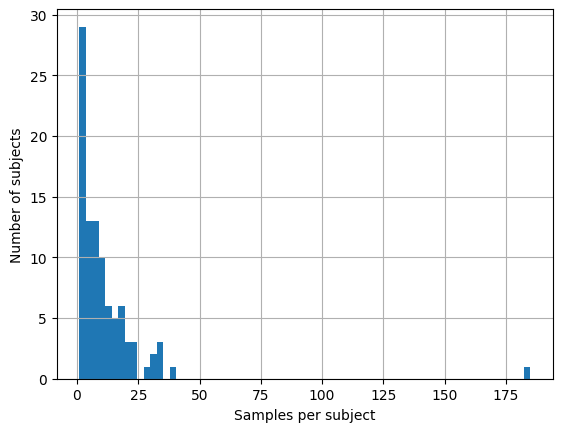

In [116]:
meta["SubjectID"].value_counts().hist(bins=70)
plt.xlabel("Samples per subject")
plt.ylabel("Number of subjects")
plt.show()

Subject 69-001 has the most samples by a great margin

### How many total reading per sample

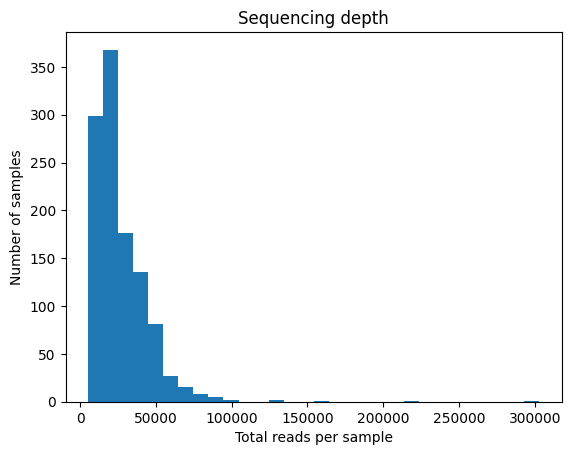

In [117]:
sample_total_abundance = otu.sum(axis=1)

plt.hist(sample_total_abundance, bins=30)
plt.xlabel("Total reads per sample")
plt.ylabel("Number of samples")
plt.title("Sequencing depth")
plt.show()

### Most common taxa:

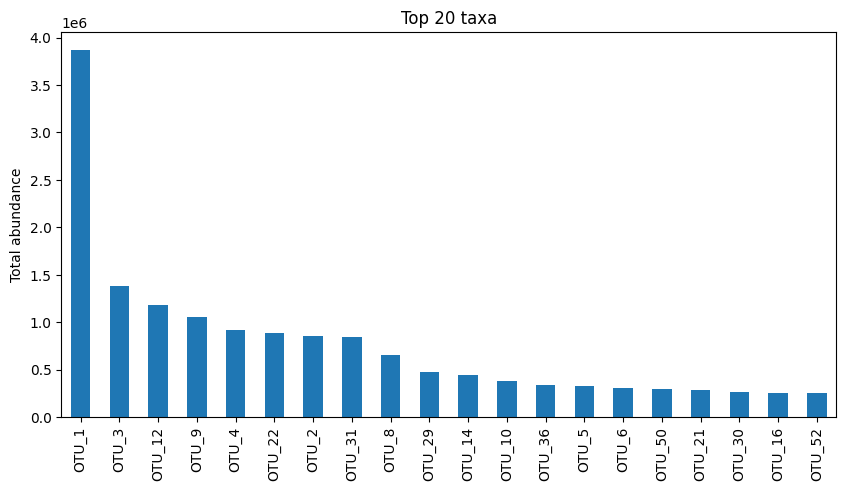

In [118]:
taxa_total_abundance = otu.sum(axis=0)  # Sum for each otu the total number of absolute abundance
taxa_total_abundance_sorted = taxa_total_abundance.sort_values(ascending=False)  # Sort the taxa
top_taxa = taxa_total_abundance_sorted.head(20)

plt.figure(figsize=(10, 5))
top_taxa.plot(kind="bar")
plt.ylabel("Total abundance")
plt.title("Top 20 taxa")
plt.show()

### Name of most common OTUs

In [119]:
# Crea una tabella con abbondanza e tassonomia
top_table = taxonomy.loc[top_taxa.index].copy()
top_table["Total abundance"] = top_taxa.values

# Metti l'abbondanza come prima colonna
top_table.insert(0, "Total abundance", top_table.pop("Total abundance"))

print(top_table.head())

        Total abundance    domain         phylum        class          order  \
OTU_1           3864563  Bacteria  Bacteroidetes  Bacteroidia  Bacteroidales   
OTU_3           1381767  Bacteria  Bacteroidetes  Bacteroidia  Bacteroidales   
OTU_12          1178184  Bacteria  Bacteroidetes  Bacteroidia  Bacteroidales   
OTU_9           1054465  Bacteria  Bacteroidetes  Bacteroidia  Bacteroidales   
OTU_4            914899  Bacteria  Bacteroidetes  Bacteroidia  Bacteroidales   

                family        genus     otu  
OTU_1   Bacteroidaceae  Bacteroides   OTU_1  
OTU_3   Bacteroidaceae  Bacteroides   OTU_3  
OTU_12  Prevotellaceae   Prevotella  OTU_12  
OTU_9   Bacteroidaceae  Bacteroides   OTU_9  
OTU_4   Bacteroidaceae  Bacteroides   OTU_4  


### Relative abundance in different samples from every patient for the top 20 taxa

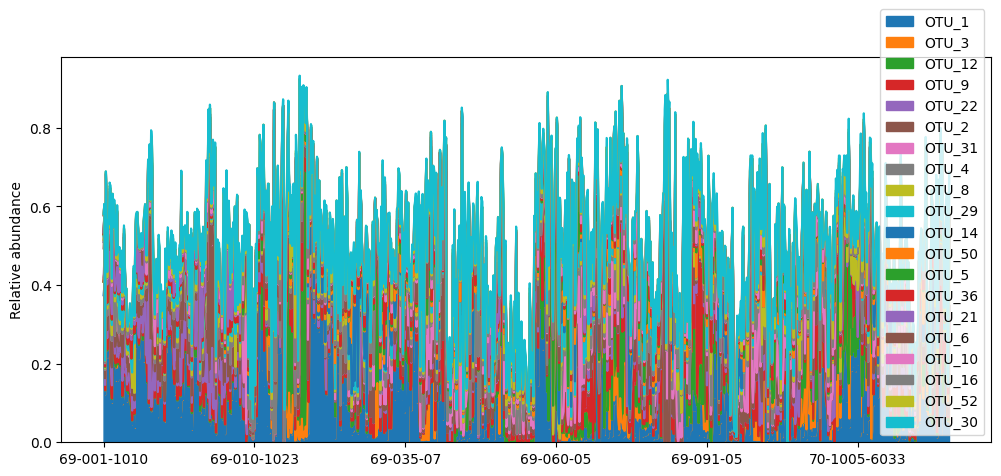

In [120]:
# Total abundance in each sample
sample_total_abundance = otu.sum(axis=1)
# Transform absolute to relative abundance
otu_rel = otu.div(sample_total_abundance, axis=0)


# Measure the mean relative abundance for each taxon on every sample
average_abundance = otu_rel.mean(axis=0)
# Sort
average_abundance_sorted = average_abundance.sort_values(ascending=False)
# Select the top 20
top_relative_abundances = average_abundance_sorted.head(20)

# Plot
otu_rel[top_relative_abundances.index].plot(kind="area", stacked=True, figsize=(12, 5))
plt.ylabel("Relative abundance")
plt.show()

### Temporal evolution of relative abundance in a single patient

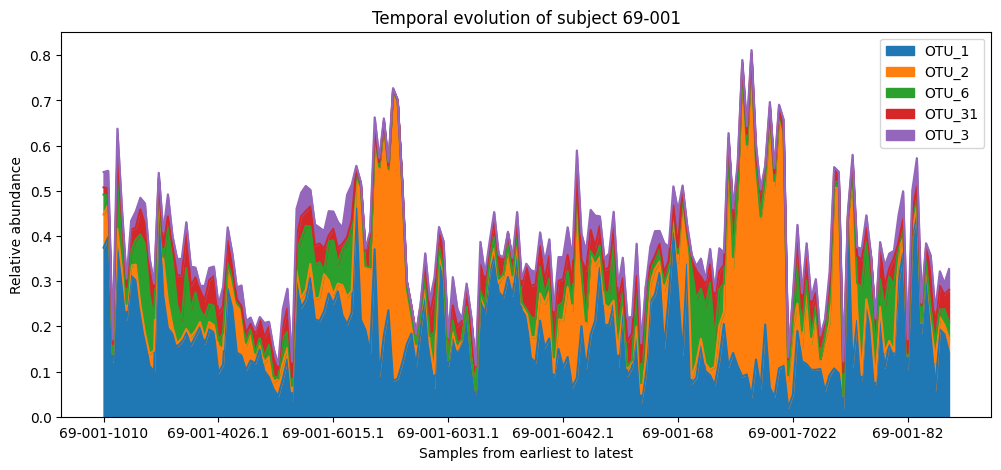

In [121]:
# Choose the patient with the most number of samples
subject_id = "69-001"

# Isolate the subject samples
meta_subject = meta[meta["SubjectID"] == subject_id]

# Sort by time
meta_subject_sorted = meta_subject.sort_values("DateZero")

# Select subject OTUs
otu_subject = otu_rel.loc[meta_subject.index]

# Find the most abundant OTUs in the subject
average_abundance = otu_subject.mean(axis=0)
top_relative_abundances = average_abundance.sort_values(ascending=False).head(5)

# Plot
otu_subject[top_relative_abundances.index].plot(
    kind="area",
    stacked=True,
    figsize=(12, 5),
)

plt.xlabel("Samples from earliest to latest")
plt.ylabel("Relative abundance")
plt.title(f"Temporal evolution of subject {subject_id}")
plt.show()